0:	learn: 0.0105274	total: 136ms	remaining: 1m 7s
100:	learn: 0.0098662	total: 661ms	remaining: 2.61s
200:	learn: 0.0094137	total: 1.18s	remaining: 1.76s
300:	learn: 0.0089351	total: 1.72s	remaining: 1.13s
400:	learn: 0.0085341	total: 2.3s	remaining: 568ms
499:	learn: 0.0081779	total: 2.9s	remaining: 0us

📊 CatBoost Performance:
MSE: 0.000067
MAPE: 28320673892.955692
R²: 0.398027
Adjusted R²: 0.391620


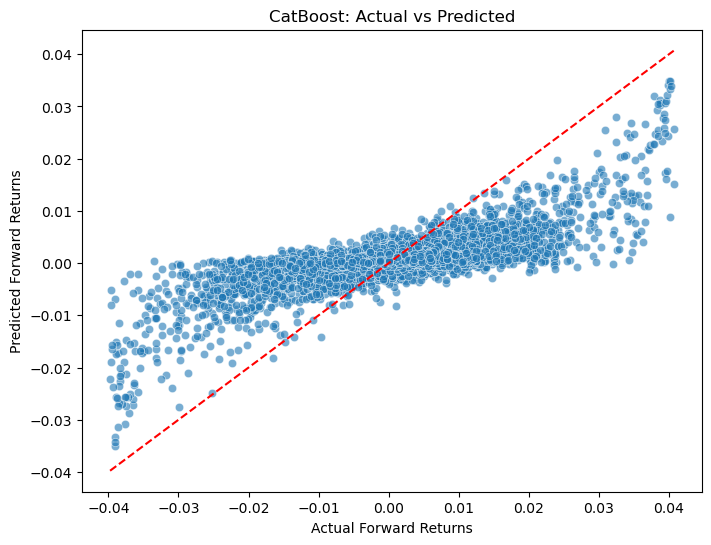

In [2]:
# STEP 0: Imports
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load train data
train = pd.read_csv(r"D:\sem project\train.csv")
train = train.ffill().fillna(0)

drop_cols = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
X_train = train.drop(columns=[c for c in drop_cols if c in train.columns])
y_train = train["forward_returns"]

# STEP 2: Train CatBoost
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)
model.fit(X_train, y_train)

# STEP 3: Load test data
test = pd.read_csv(r"D:\sem project\test.csv")
test = test.ffill().fillna(0)
extra_cols = set(test.columns) - set(X_train.columns)
test = test.drop(columns=list(extra_cols))
X_test = test[X_train.columns]

# STEP 4: Predict allocations
test_preds = model.predict(X_test)
allocations = 1 + test_preds / test_preds.std()
allocations = allocations.clip(0, 2)

# STEP 5: Evaluation on training data
y_pred_train = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred_train)
mape = mean_absolute_percentage_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
n, p = X_train.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n📊 CatBoost Performance:")
print(f"MSE: {mse:.6f}")
print(f"MAPE: {mape:.6f}")
print(f"R²: {r2:.6f}")
print(f"Adjusted R²: {adj_r2:.6f}")

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.6)
plt.xlabel("Actual Forward Returns")
plt.ylabel("Predicted Forward Returns")
plt.title("CatBoost: Actual vs Predicted")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.show()


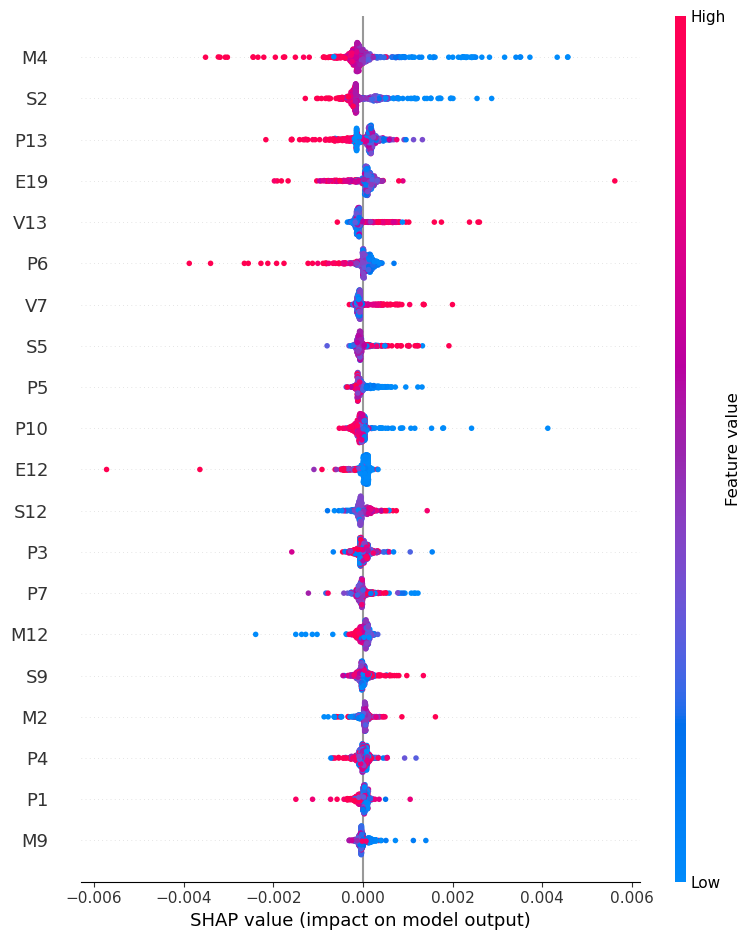

In [4]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt

# --- SHAP for CatBoost ---

# Use a sample of data as background to speed up SHAP calculations
background = X_train.sample(500, random_state=42)

# Create TreeExplainer for CatBoost model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(background)

# Plot SHAP summary plot
shap.summary_plot(shap_values, background, show=True)

# Save SHAP plot if you want
plt.savefig("shap_catboost_summary.png", dpi=300, bbox_inches='tight')
plt.close()


# --- LIME for CatBoost ---

# Initialize LimeTabularExplainer with training data
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# Choose a random instance from training set to explain
idx = np.random.randint(0, len(X_train))
instance = X_train.iloc[idx]

# Explain instance prediction with LIME
lime_exp = lime_explainer.explain_instance(
    data_row=instance.values,
    predict_fn=model.predict,
    num_features=10  # Top 10 features in explanation
)

# Show explanation inline if in Jupyter notebook
lime_exp.show_in_notebook()

# Save explanation as interactive HTML file
lime_exp.save_to_file("lime_catboost_explanation.html")
